In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cleanly import the fuzzycore package!
import fuzzycore.solver as solver
import fuzzycore.plotting as plotting
import fuzzycore.utils as utils
import fuzzycore.constants as c

# Visualization Settings
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12


# Dilute core Jupiter Model

Warm Start: Found similar model in DB. Initial log_Pc = 8.5750
Solving for 1.0 M_J planet...

🛑 [FUZZYCORE TRIPWIRE: EXACT INPUTS RECEIVED] 🛑
Trial ID: Jupiter_WarmStart | Mode: mass
Target Value: 1.89800e+27 [kg]
   -> Equivalent to: 317.82 Earth Masses
   -> Equivalent to: 1.00000 Jupiter Masses
------------------------------------------------------------
Raw Parameters Dictionary:
  - M_core: 5.972e+25 ⚠️ (MASSIVE NUMBER)
  - P_surf: 1.0
  - T_surf: 200.0
  - z_base: 0.01
  - sigma_val: 0.0
  - debug: True
  - initial_log_pc: 8.575006329709602
  - z_profile: ndarray (shape: (1,), mean: 0.010)

--- Loading Raw EOS Tables (From Disk) ---
  > Loading Hydrogen...
  > Loading Helium...
  > Loading Water...
  > Loading Rock...
  > Loading Iron...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructio

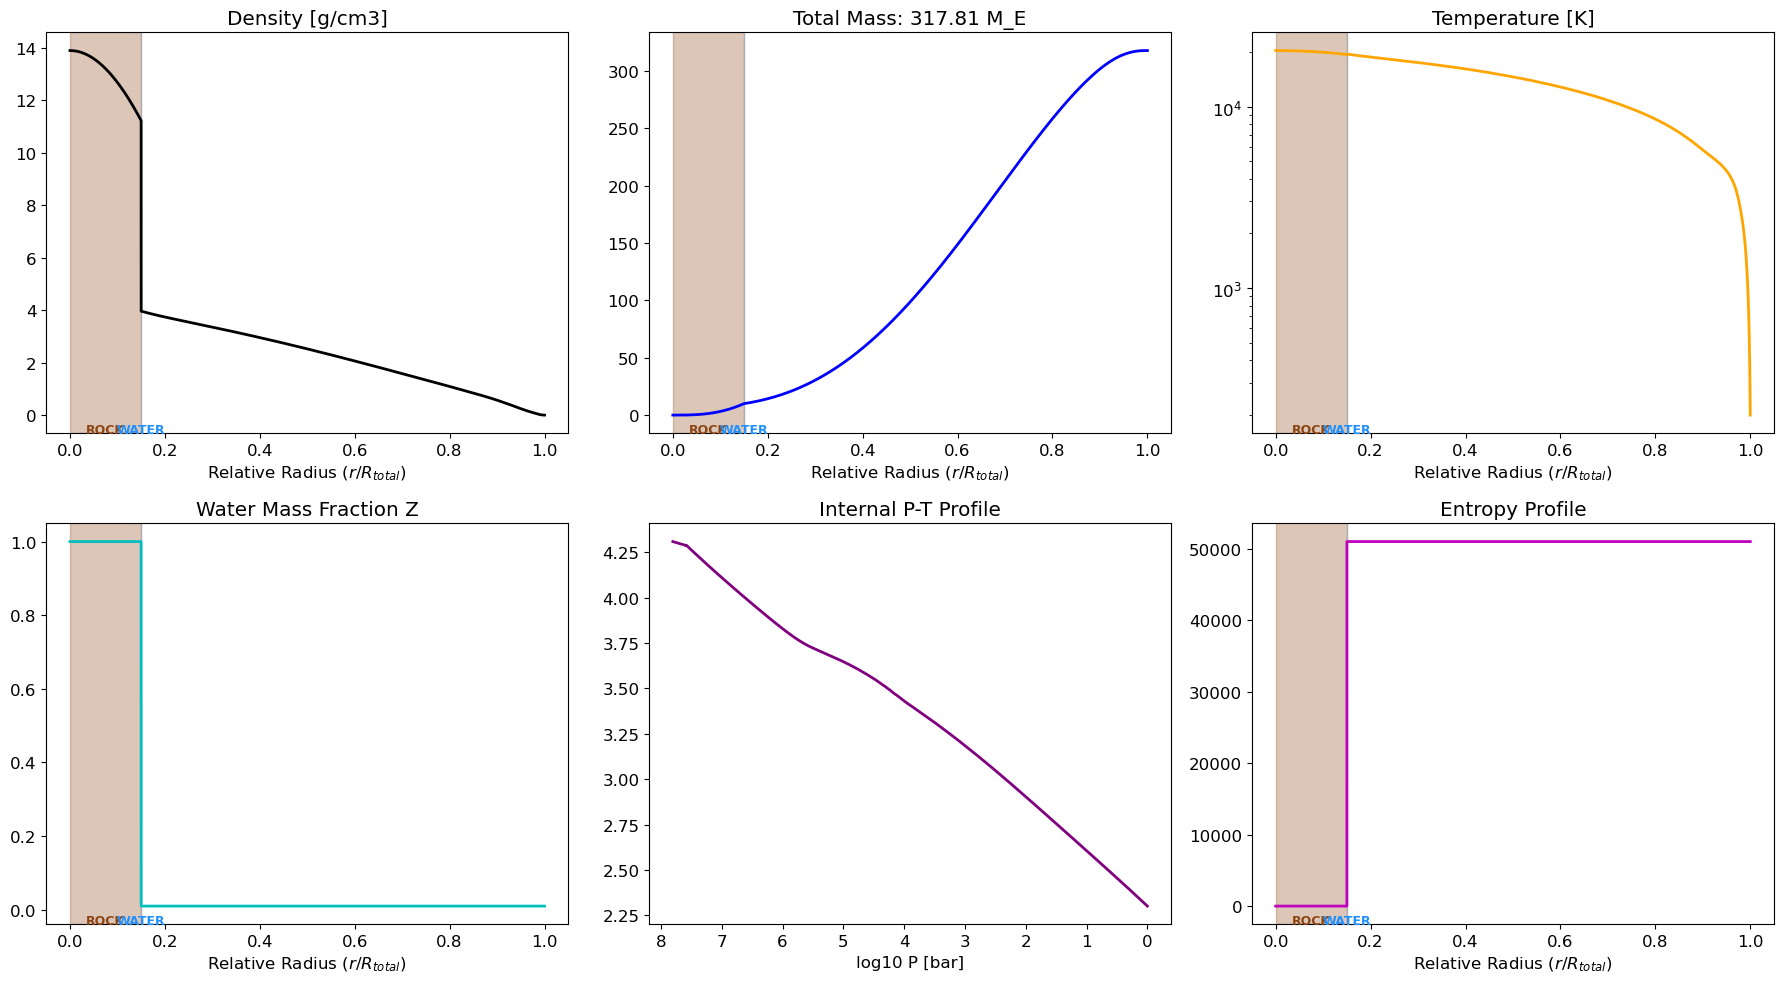

Figure saved to: ../figures/eos_trajectory.pdf


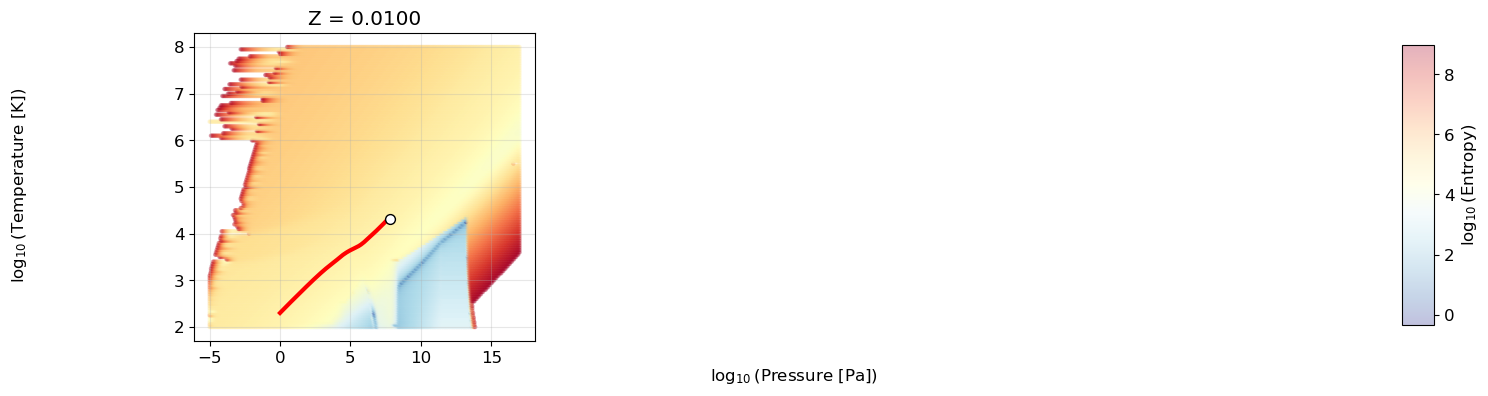

In [2]:
# 2. Setup Parameters for the target model
target_mass = 1.0 * c.M_JUPITER
params = {
    'M_core': 10.0 * c.M_EARTH,   
    'P_surf': 1.0,               
    'T_surf': 200.0,             
    'z_base': 0.01,              
    'sigma_val': 0.0,    
    'debug': True        
}

# 3. Extract Initial Guess from Database
db_path = "../data/dilute_core_p_surf_study.csv"
initial_log_pc = 12.5  # Default fallback

if os.path.exists(db_path):
    df_db = pd.read_csv(db_path)
    # Filter for successful runs with similar parameters
    success_df = df_db[df_db['status'].str.contains('success', na=False)].copy()
    
    if not success_df.empty:
        # Find the model closest in Mass and Temperature
        success_df['dist'] = (
            np.abs(success_df['M_total_Mj'] - (target_mass / c.M_JUPITER)) + 
            np.abs(success_df['T_surf_K'] - params['T_surf']) / 100.0
        )
        best_match = success_df.loc[success_df['dist'].idxmin()]
        initial_log_pc = np.log10(best_match['P_center_bar'])
        print(f"Warm Start: Found similar model in DB. Initial log_Pc = {initial_log_pc:.4f}")
    else:
        print("DB exists but no successful models found. Using default guess.")
else:
    print("Database not found. Using default guess.")

params['initial_log_pc'] = initial_log_pc

# 4. Generate high-resolution Z-profile
params['z_profile'] = np.round(utils.generate_gaussian_z_profile(
    n_layers=100, 
    sigma=params['sigma_val'], 
    z_base=params['z_base'], 
    z_core=0.99
), 3)

# 5. Solve for the internal structure
print(f"Solving for {target_mass / c.M_JUPITER:.1f} M_J planet...")

result = solver.solve_structure(
    target_val=target_mass, 
    params=params, 
    mode='mass', 
    trial_id="Jupiter_WarmStart", 
    csv_file="../data/test_run.csv", 
    write_lock=utils.DummyLock() 
)

# 6. Check results and plot
if result:
    print(f"Success! Calculated Mass: {result['M'][-1] / c.M_JUPITER:.3f} M_J")
    print(f"Radius found: {np.max(result['R']) / c.R_JUPITER:.3f} R_J")
    
    # Visualize
    plotting.plot_diagnostics(result)
    plotting.plot_trajectory_on_eos(result, params, max_plots=9)
else:
    print("Solver failed to converge on a valid structure.")

Warm Start: Found similar model in DB. Initial log_Pc = 8.3075
Solving for 1.0 M_J planet...
[START] Pc=6.42e+07 -> P_int=3.99e+07 -> T_int=53515.0 K
[SUCCESS] M=1.489 Mj
[START] Pc=6.42e+08 -> P_int=5.33e+08 -> T_int=142156.6 K
[SUCCESS] M=5.376 Mj
[START] Pc=2.03e+07 -> P_int=7.88e+06 -> T_int=31716.4 K
[SUCCESS] M=0.589 Mj
[START] Pc=6.42e+07 -> P_int=3.99e+07 -> T_int=53515.0 K
[SUCCESS] M=1.489 Mj
[START] Pc=2.03e+07 -> P_int=7.88e+06 -> T_int=31716.4 K
[SUCCESS] M=0.589 Mj
[START] Pc=6.42e+07 -> P_int=3.99e+07 -> T_int=53515.0 K
[SUCCESS] M=1.489 Mj
[START] Pc=4.79e+07 -> P_int=2.76e+07 -> T_int=47214.0 K
[SUCCESS] M=1.224 Mj
[START] Pc=5.01e+07 -> P_int=2.93e+07 -> T_int=48087.3 K
[SUCCESS] M=1.262 Mj
[START] Pc=5.01e+07 -> P_int=2.93e+07 -> T_int=48119.2 K
[SUCCESS] M=1.263 Mj
[START] Pc=5.02e+07 -> P_int=2.93e+07 -> T_int=48123.2 K
[SUCCESS] M=1.263 Mj
[START] Pc=5.02e+07 -> P_int=2.93e+07 -> T_int=48123.2 K
[SUCCESS] M=1.263 Mj
Success! Calculated Mass: 1.263 M_J
Radius found

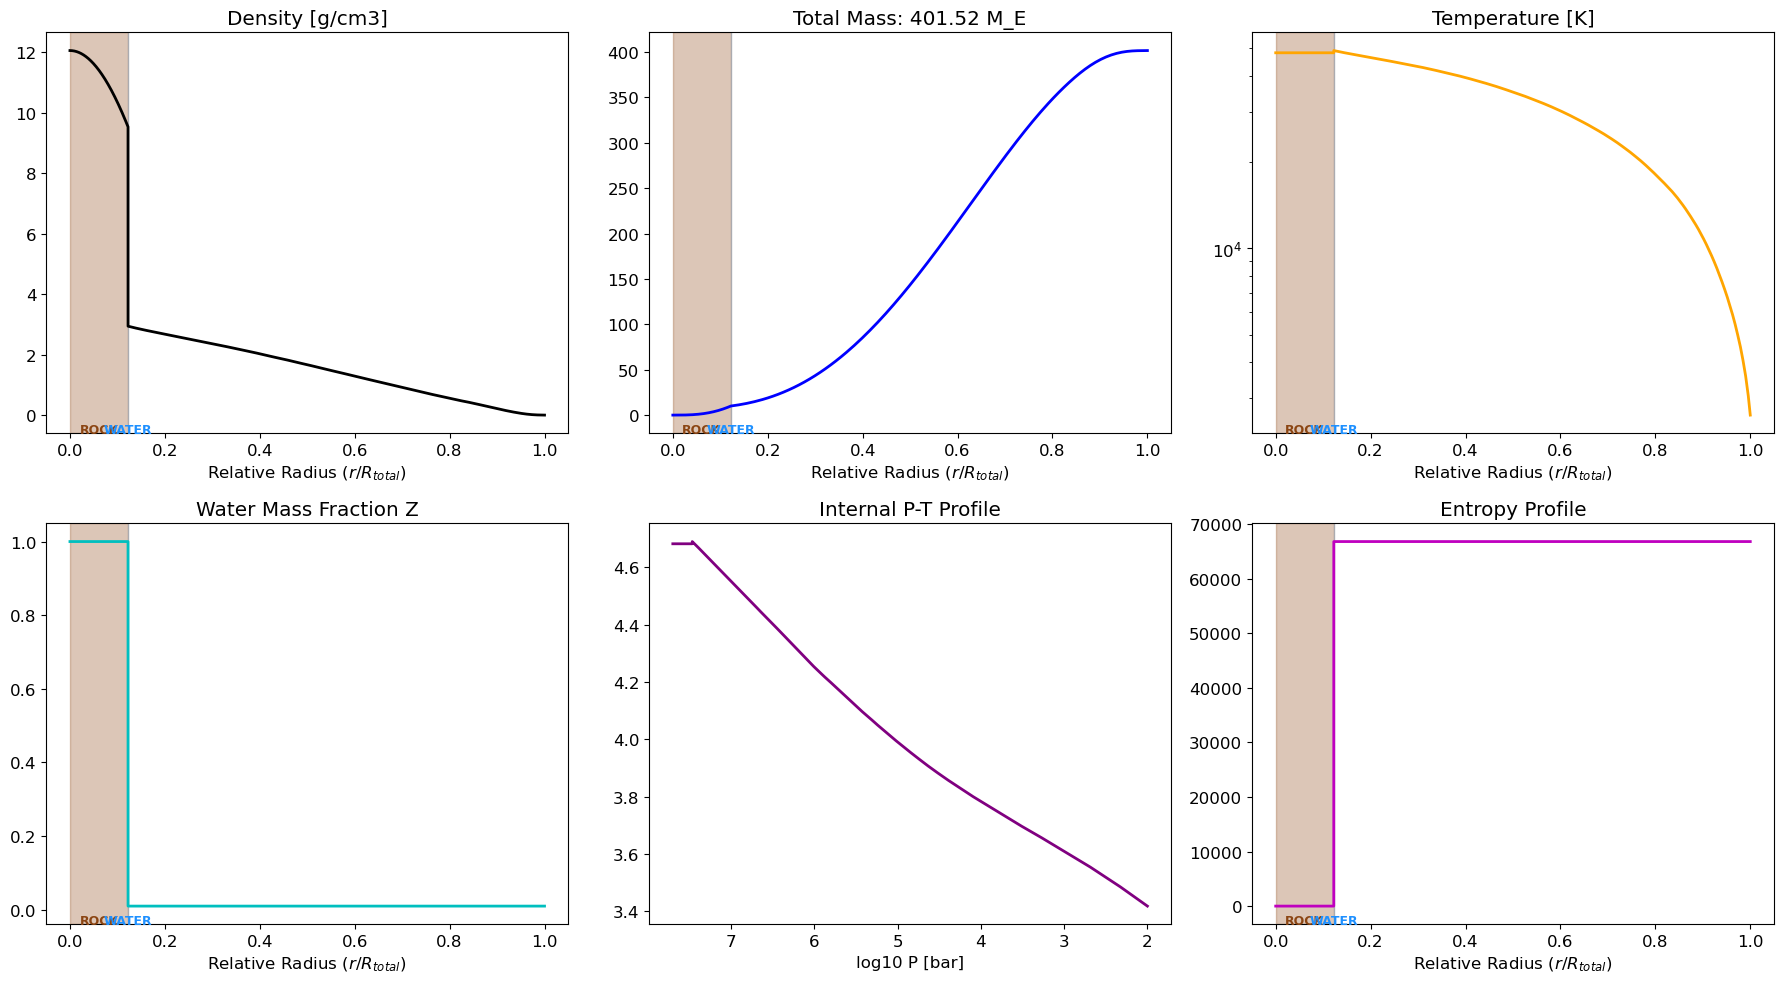

Figure saved to: ../figures/eos_trajectory.pdf


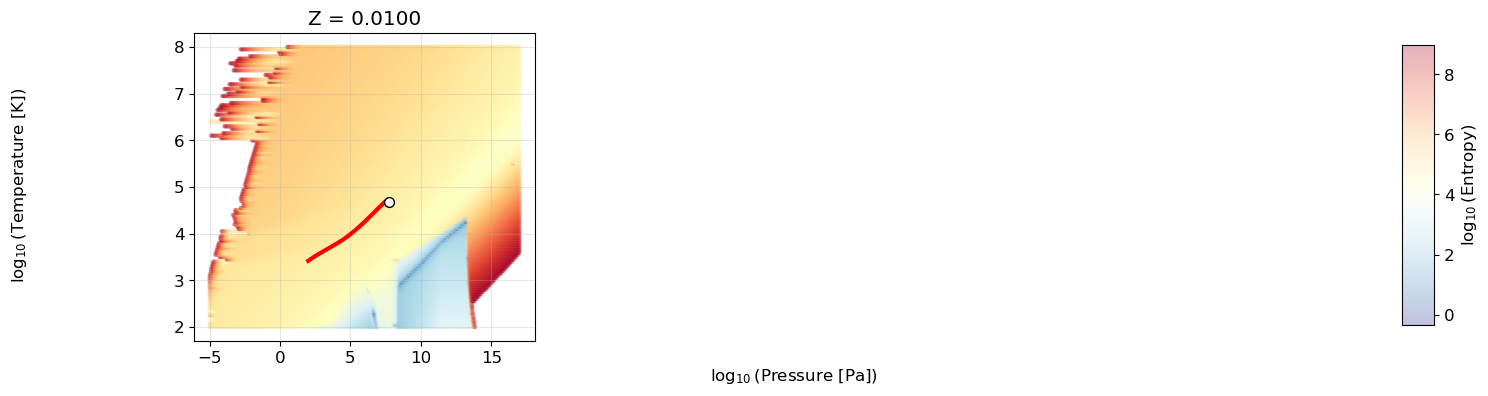

In [6]:
# 2. Setup Parameters for the target model
target_gravity = 19.56
params = {
    'M_core': 10.0 * c.M_EARTH,   
    'P_surf': 100.0,               
    'T_surf': 2616.3,             
    'z_base': 0.01,              
    'sigma_val': 0,    
    'debug': True        
}

# 3. Extract Initial Guess from Database
db_path = "../data/dilute_core_p_surf_study.csv"
initial_log_pc = 12.5  # Default fallback

if os.path.exists(db_path):
    df_db = pd.read_csv(db_path)
    # Filter for successful runs with similar parameters
    success_df = df_db[df_db['status'].str.contains('success', na=False)].copy()
    
    if not success_df.empty:
        # Find the model closest in Mass and Temperature
        success_df['dist'] = (
            np.abs(success_df['M_total_Mj'] - (target_mass / c.M_JUPITER)) + 
            np.abs(success_df['T_surf_K'] - params['T_surf']) / 100.0
        )
        best_match = success_df.loc[success_df['dist'].idxmin()]
        initial_log_pc = np.log10(best_match['P_center_bar'])
        print(f"Warm Start: Found similar model in DB. Initial log_Pc = {initial_log_pc:.4f}")
    else:
        print("DB exists but no successful models found. Using default guess.")
else:
    print("Database not found. Using default guess.")

params['initial_log_pc'] = initial_log_pc

# 4. Generate high-resolution Z-profile
params['z_profile'] = np.round(utils.generate_gaussian_z_profile(
    n_layers=100, 
    sigma=params['sigma_val'], 
    z_base=params['z_base'], 
    z_core=0.99
), 3)

# 5. Solve for the internal structure
print(f"Solving for {target_mass / c.M_JUPITER:.1f} M_J planet...")

result = solver.solve_structure(
    target_val=target_gravity, 
    params=params, 
    mode='gravity', 
    trial_id="Jupiter_WarmStart", 
    csv_file="../data/test_run.csv", 
    write_lock=utils.DummyLock() 
)

# 6. Check results and plot
if result:
    print(f"Success! Calculated Mass: {result['M'][-1] / c.M_JUPITER:.3f} M_J")
    print(f"Radius found: {np.max(result['R']) / c.R_JUPITER:.3f} R_J")
    
    # Visualize
    plotting.plot_diagnostics(result)
    plotting.plot_trajectory_on_eos(result, params, max_plots=9)
else:
    print("Solver failed to converge on a valid structure.")

---------

# GJ1214 b Analogue

Solving for 8.17 Me Water World...
  > Rock:  6.50 Me
  > Water: 1.50 Me
  > Env:   0.17 Me

🛑 [FUZZYCORE TRIPWIRE: EXACT INPUTS RECEIVED] 🛑
Trial ID: GJ_1214_b_Hycean | Mode: mass
Target Value: 4.87912e+25 [kg]
   -> Equivalent to: 8.17 Earth Masses
   -> Equivalent to: 0.02571 Jupiter Masses
------------------------------------------------------------
Raw Parameters Dictionary:
  - M_rock: 3.882e+25 ⚠️ (MASSIVE NUMBER)
  - M_water: 8.958e+24 ⚠️ (MASSIVE NUMBER)
  - P_surf: 1.0
  - T_surf: 550.0
  - z_base: 0.02
  - sigma_val: 0.25
  - iron_fraction: 0.33
  - debug: True
  - initial_log_pc: 8.0
  - z_profile: ndarray (shape: (100,), mean: 0.326)

  [Smart Prior] Mined historical model. Prior guess set to logPc=6.780
  [Solver] Launching concentric bracket search around logPc=6.78...
  [Env Builder] Integrating from 1.00 to 18.43 bar.
  [Env Builder] Z-jump 0.020->0.021: Entropy jumped from 62297.02 to 62234.07
  [Env Builder] Z-jump 0.021->0.022: Entropy jumped from 62234.07 to 62171.

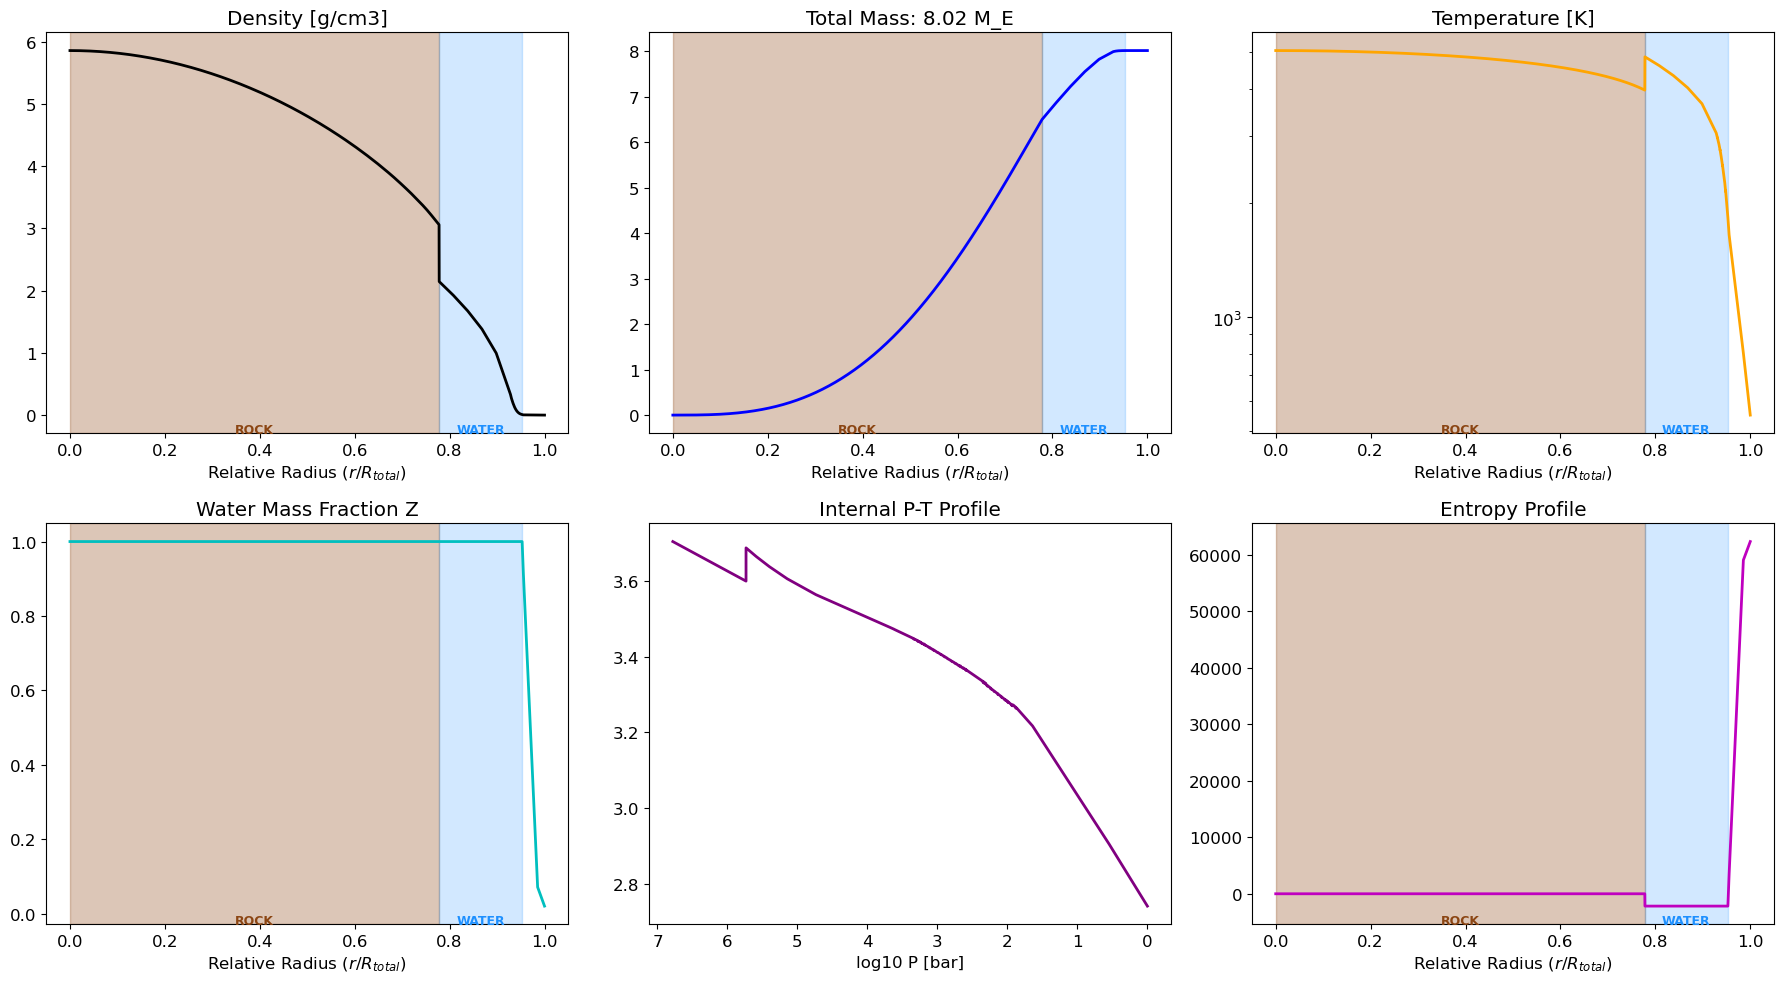

In [3]:
# 1. Setup Parameters for K2-18b (Hycean Candidate)
GJ_1214_b = 8.17 * c.M_EARTH  # Refined Mass

params = {
    # Interior: Must be small to allow a massive, thick envelope
    'M_rock': 7.5 * c.M_EARTH,   
    
    # We set water to 0.0. Kepler-11e is too hot and gas-dominated 
    # for a distinct liquid/ice mantle. Metals are mixed in the envelope.
    'M_water': 0.5 * c.M_EARTH,  
    
    # Surface Conditions
    'P_surf': 1.0,               
    'T_surf': 550.0,  # Kepler-11e is highly irradiated (T_eq is ~880-900 K)
    
    # Atmosphere Composition
    'z_base': 0.02,   # Mostly H/He at the surface
    
    # A wide dilute region (fuzzy core) lofts heavy elements into the 
    # envelope, restricting convection and puffing the radius up even further.
    'sigma_val': 0.25, 
    
    # Iron fraction for the rock core (Earth-like)
    'iron_fraction': 0.33,
    
    'debug': True           
}

# Calculated Envelope Mass: 8.6 - 8.0 = 0.6 Me (~7% envelope, realistic for Mini-Neptune)

# 2. Extract Initial Guess (Warm Start)
db_path = "../data/dilute_core_p_surf_study.csv"
initial_log_pc = 8.0 # Core pressure will be higher for a solid planet (~30 Mbar)

if os.path.exists(db_path):
    try:
        df_db = pd.read_csv(db_path)
        # Filter for successful runs
        success_df = df_db[df_db['status'].astype(str).str.contains('success', na=False)].copy()
        
        if not success_df.empty:
            # Find nearest mass neighbor
            success_df['dist'] = np.abs(success_df['M_total_Mj'] - (GJ_1214_b/c.M_JUPITER))
            best_match = success_df.loc[success_df['dist'].idxmin()]
            
            # Sanity check the pressure (don't blindly trust a Jupiter run for a Earth run)
            found_pc = np.log10(best_match['P_center_bar'])
            if 9.0 < found_pc < 13.0:
                initial_log_pc = found_pc
                print(f"Warm Start: Found similar model. Initial log_Pc = {initial_log_pc:.4f}")
    except:
        print("Database read error. Using default.")

params['initial_log_pc'] = initial_log_pc

# 3. Generate Z-profile (H/He Surface -> Water/Rock Interior)
params['z_profile'] = np.round(utils.generate_gaussian_z_profile(
    n_layers=100, 
    sigma=params['sigma_val'], 
    z_base=params['z_base'], 
    z_core=0.99
), 3)

# 4. Run Solver
# The solver detects 'M_water' and uses the 3-layer integrator automatically
print(f"Solving for {GJ_1214_b/c.M_EARTH:.2f} Me Water World...")
print(f"  > Rock:  {params['M_rock']/c.M_EARTH:.2f} Me")
print(f"  > Water: {params['M_water']/c.M_EARTH:.2f} Me")
print(f"  > Env:   {(GJ_1214_b - params['M_rock'] - params['M_water'])/c.M_EARTH:.2f} Me")

result = solver.solve_structure(
    target_val=GJ_1214_b, 
    params=params, 
    mode='mass', 
    trial_id="GJ_1214_b_Hycean", 
    csv_file="hycean_runs.csv", 
    write_lock=utils.DummyLock() 
)

# 5. Quick Result Check
if result:
    print("\n--- SOLUTION FOUND ---")
    print(f"Total Mass:   {result['M_total']/c.M_EARTH:.3f} M_E")
    print(f"Total Radius: {result['R_total']/c.R_EARTH:.3f} R_E")
    print(f"Core Radius:  {result['R_rock']/c.R_EARTH:.3f} R_E (Rock)")
    print(f"Water Top:    {result['R_int']/c.R_EARTH:.3f} R_E")
    
    # Plotting
    plotting.plot_diagnostics(result, save_name="GJ_1214_b_structure")
else:
    print("\n[FAILED] Solver could not converge.")

---------

# Kepler11 e Analigue

Solving for 7.95 Me Water World...
  > Rock:  7.00 Me
  > Water: 0.20 Me
  > Env:   0.75 Me

🛑 [FUZZYCORE TRIPWIRE: EXACT INPUTS RECEIVED] 🛑
Trial ID: Kepler11e_Hycean | Mode: mass
Target Value: 4.74475e+25 [kg]
   -> Equivalent to: 7.95 Earth Masses
   -> Equivalent to: 0.02500 Jupiter Masses
------------------------------------------------------------
Raw Parameters Dictionary:
  - M_rock: 4.180e+25 ⚠️ (MASSIVE NUMBER)
  - M_water: 1.194e+24 ⚠️ (MASSIVE NUMBER)
  - P_surf: 1.0
  - T_surf: 900.0
  - z_base: 0.02
  - sigma_val: 0.25
  - iron_fraction: 0.33
  - debug: True
  - initial_log_pc: 8.0
  - z_profile: ndarray (shape: (100,), mean: 0.326)

  [Smart Prior] Mined historical model with mass 0.0250 Mj.
  [Smart Prior] Overriding initial_log_pc to 6.777
Designing core + water + enveloppe

  [Scout] Searching for Water/Gas boundary to fit 0.20 M_E of water.
  [Scout] ❌ Rock core reaches the surface. No room for water mantle!
  [Solver] logPc 6.28: Integration returned None
Designing 

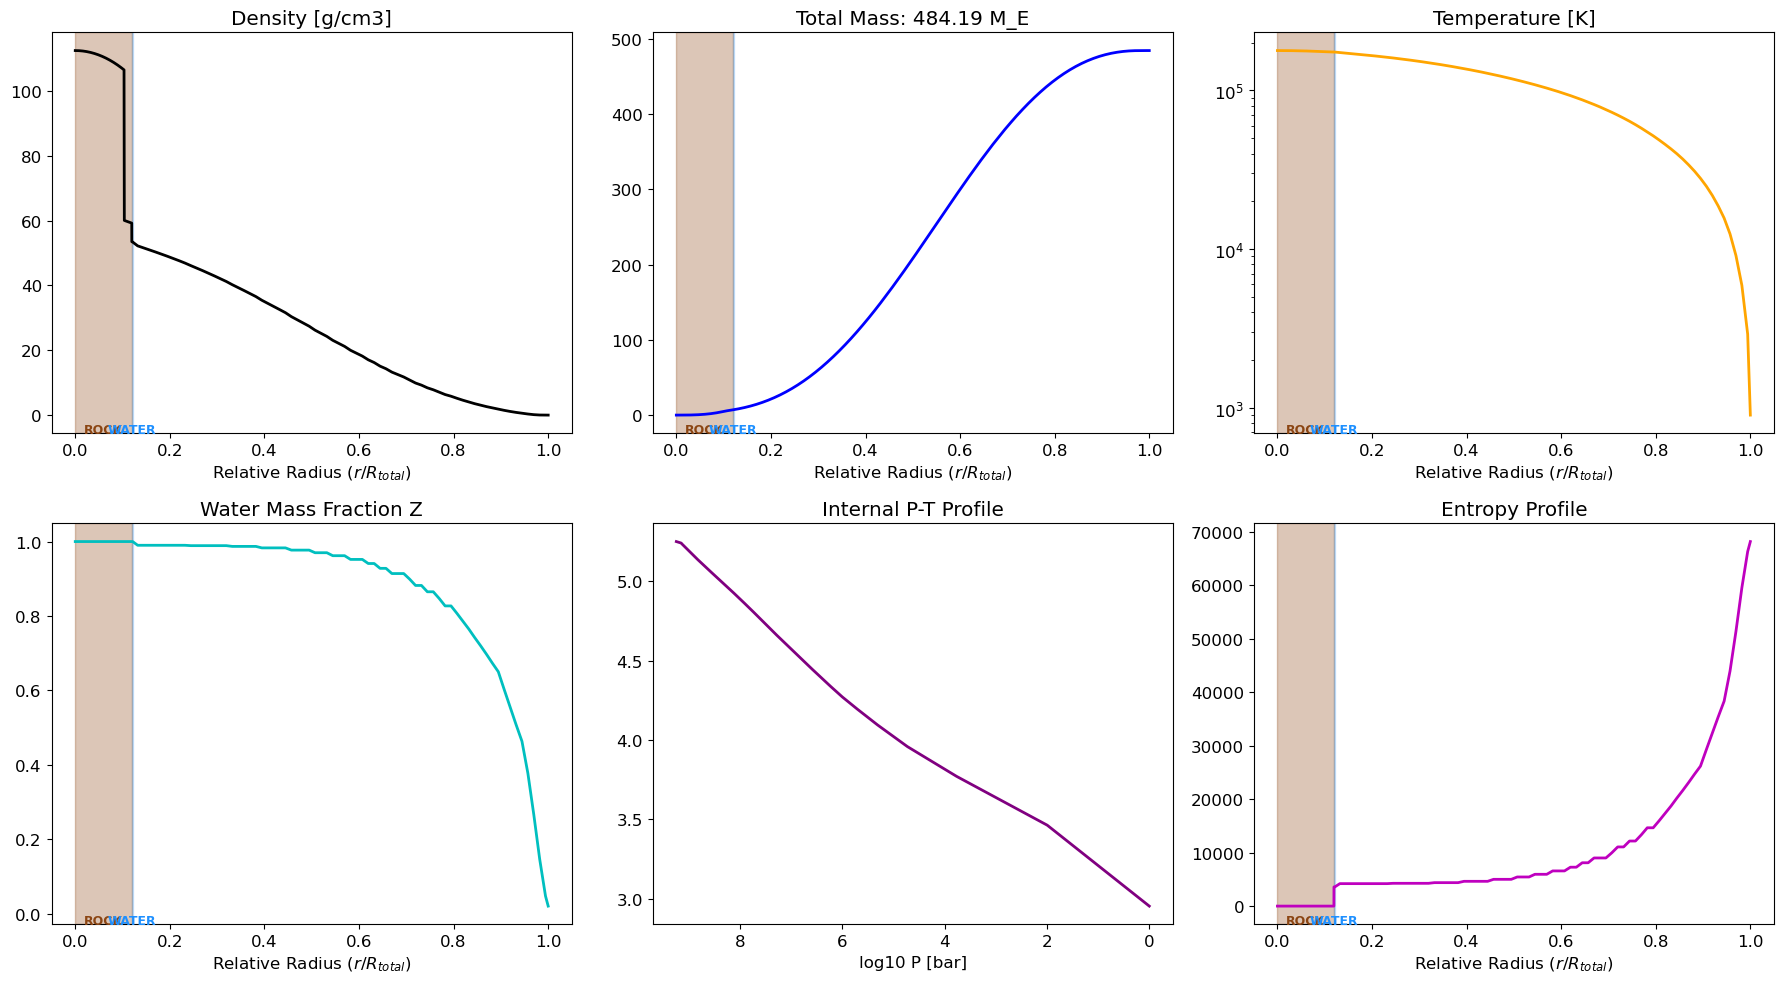

In [ ]:
# 1. Setup Parameters for K2-18b (Hycean Candidate)
M_Kepler11e = 7.945 * c.M_EARTH  # Refined Mass

params = {
    # Interior: Must be small to allow a massive, thick envelope
    'M_rock': 7 * c.M_EARTH,   
    
    # We set water to 0.0. Kepler-11e is too hot and gas-dominated 
    # for a distinct liquid/ice mantle. Metals are mixed in the envelope.
    'M_water': 0.2 * c.M_EARTH,  
    
    # Surface Conditions
    'P_surf': 1.0,               
    'T_surf': 900.0,  # Kepler-11e is highly irradiated (T_eq is ~880-900 K)
    
    # Atmosphere Composition
    'z_base': 0.02,   # Mostly H/He at the surface
    
    # A wide dilute region (fuzzy core) lofts heavy elements into the 
    # envelope, restricting convection and puffing the radius up even further.
    'sigma_val': 0.25, 
    
    # Iron fraction for the rock core (Earth-like)
    'iron_fraction': 0.33,
    
    'debug': True           
}

# Calculated Envelope Mass: 8.6 - 8.0 = 0.6 Me (~7% envelope, realistic for Mini-Neptune)

# 2. Extract Initial Guess (Warm Start)
db_path = "dilute_core_p_surf_study.csv"
initial_log_pc = 8.0 # Core pressure will be higher for a solid planet (~30 Mbar)

if os.path.exists(db_path):
    try:
        df_db = pd.read_csv(db_path)
        # Filter for successful runs
        success_df = df_db[df_db['status'].astype(str).str.contains('success', na=False)].copy()
        
        if not success_df.empty:
            # Find nearest mass neighbor
            success_df['dist'] = np.abs(success_df['M_total_Mj'] - (M_Kepler11e/c.M_JUPITER))
            best_match = success_df.loc[success_df['dist'].idxmin()]
            
            # Sanity check the pressure (don't blindly trust a Jupiter run for a Earth run)
            found_pc = np.log10(best_match['P_center_bar'])
            if 9.0 < found_pc < 13.0:
                initial_log_pc = found_pc
                print(f"Warm Start: Found similar model. Initial log_Pc = {initial_log_pc:.4f}")
    except:
        print("Database read error. Using default.")

params['initial_log_pc'] = initial_log_pc

# 3. Generate Z-profile (H/He Surface -> Water/Rock Interior)
params['z_profile'] = np.round(utils.generate_gaussian_z_profile(
    n_layers=100, 
    sigma=params['sigma_val'], 
    z_base=params['z_base'], 
    z_core=0.99
), 3)

# 4. Run Solver
# The solver detects 'M_water' and uses the 3-layer integrator automatically
print(f"Solving for {M_Kepler11e/c.M_EARTH:.2f} Me Water World...")
print(f"  > Rock:  {params['M_rock']/c.M_EARTH:.2f} Me")
print(f"  > Water: {params['M_water']/c.M_EARTH:.2f} Me")
print(f"  > Env:   {(M_Kepler11e - params['M_rock'] - params['M_water'])/c.M_EARTH:.2f} Me")

result = solver.solve_structure(
    target_val=M_Kepler11e, 
    params=params, 
    mode='mass', 
    trial_id="Kepler11e_Hycean", 
    csv_file="hycean_runs.csv", 
    write_lock=utils.DummyLock() 
)

# 5. Quick Result Check
if result:
    print("\n--- SOLUTION FOUND ---")
    print(f"Total Mass:   {result['M_total']/c.M_EARTH:.3f} M_E")
    print(f"Total Radius: {result['R_total']/c.R_EARTH:.3f} R_E")
    print(f"Core Radius:  {result['R_rock']/c.R_EARTH:.3f} R_E (Rock)")
    print(f"Water Top:    {result['R_int']/c.R_EARTH:.3f} R_E")
    
    # Plotting
    plotting.plot_diagnostics(result, save_name="Kepler11e_structure")
else:
    print("\n[FAILED] Solver could not converge.")

Success! Final Mass: 484.191 Me
Success! Final Radius: 6.292 Me
Figure saved to: ../figures/Kepler11e_structure.pdf


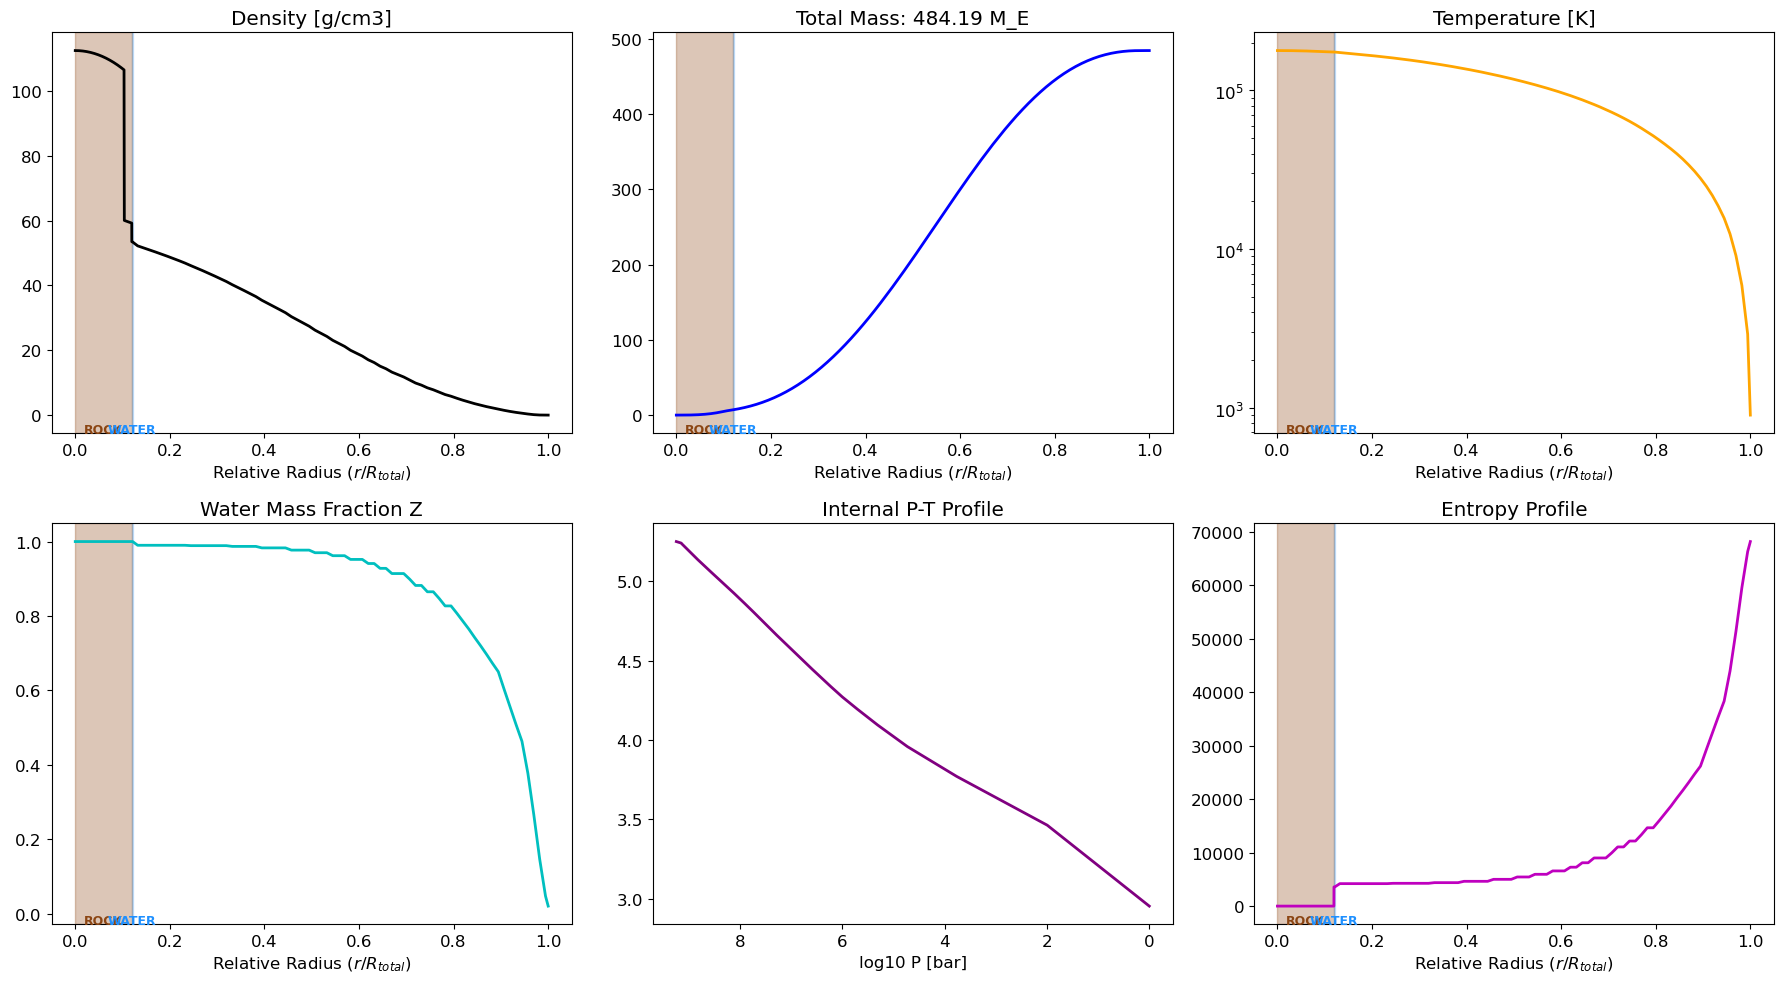

Figure saved to: ../figures/Kepler11e_trajetory.pdf


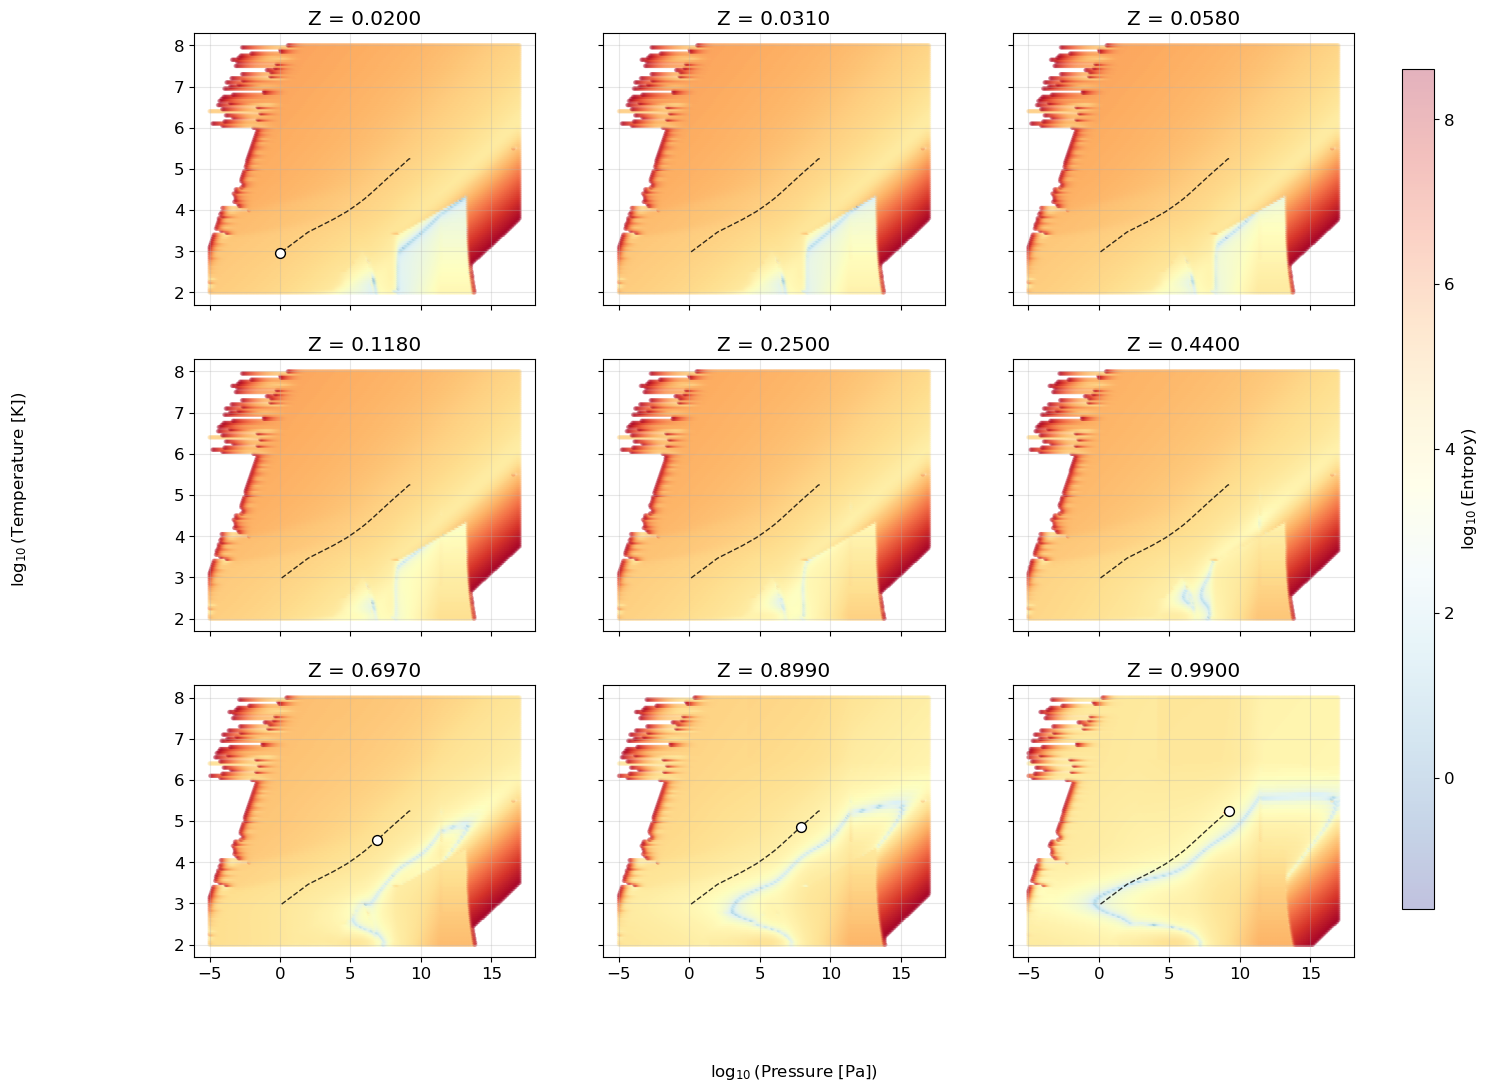

In [ ]:

if result:
    print(f"Success! Final Mass: {result['M'][-1]/c.M_EARTH:.3f} Me")
    print(f"Success! Final Radius: {result['R'][-1]/c.R_EARTH:.3f} Me")
    # Diagnostics will show the water-to-gas transition
    plotting.plot_diagnostics(result, save_name="Kepler11e_structure")
    plotting.plot_trajectory_on_eos(result, params, max_plots=9, save_name="Kepler11e_trajetory")